In [11]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

In [12]:
# Load the cleaned dataset
df = pd.read_csv("heart-cleaned.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (746, 12)

First few rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
# Separate features and target
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# Identify numerical and categorical columns
numerical_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"\nTarget distribution:")
print(y.value_counts())

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Target distribution:
HeartDisease
0    390
1    356
Name: count, dtype: int64


In [14]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {X_encoded.shape}")
print(f"\nFeature names:")
print(X_encoded.columns.tolist())

Shape after encoding: (746, 15)

Feature names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set size: 596
Test set size: 150

Training target distribution:
HeartDisease
0    312
1    284
Name: count, dtype: int64

Test target distribution:
HeartDisease
0    78
1    72
Name: count, dtype: int64


In [16]:
# Standardize the numerical features (important for SVM)
scaler = StandardScaler()

# Fit scaler on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Standardization completed!")
print(f"\nTraining data statistics (first 5 features):")
print(X_train_scaled.iloc[:, :5].describe())

Standardization completed!

Training data statistics (first 5 features):
                Age     RestingBP   Cholesterol     FastingBS         MaxHR
count  5.960000e+02  5.960000e+02  5.960000e+02  5.960000e+02  5.960000e+02
mean   2.622809e-16  7.004092e-16 -1.132577e-16  2.980464e-18 -3.382827e-16
std    1.000840e+00  1.000840e+00  1.000840e+00  1.000840e+00  1.000840e+00
min   -2.566062e+00 -2.372674e+00 -2.666052e+00 -4.408954e-01 -2.940569e+00
25%   -7.641812e-01 -7.740312e-01 -6.014289e-01 -4.408954e-01 -7.540736e-01
50%    8.376293e-02 -2.030874e-01 -1.389533e-01 -4.408954e-01 -1.149038e-02
75%    7.197210e-01  4.392244e-01  5.052091e-01 -4.408954e-01  8.136021e-01
max    2.521602e+00  3.793519e+00  5.889746e+00  2.268112e+00  2.257514e+00


In [17]:
# Train SVM model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")
print(f"Number of support vectors: {len(svm_model.support_vectors_)}")
print(f"Support vectors per class: {svm_model.n_support_}")

SVM model trained successfully!
Number of support vectors: 273
Support vectors per class: [134 139]


In [18]:
# Make predictions
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("SVM MODEL PERFORMANCE")
print("=" * 50)
print(f"\nTrain Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n" + "=" * 50)
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test, y_test_pred, target_names=["0: No Heart Disease", "1: Heart Disease"]
    )
)

SVM MODEL PERFORMANCE

Train Accuracy: 0.9195 (91.95%)
Test Accuracy: 0.8600 (86.00%)


Confusion Matrix (Test Set):
[[66 12]
 [ 9 63]]

Classification Report (Test Set):
                     precision    recall  f1-score   support

0: No Heart Disease       0.88      0.85      0.86        78
   1: Heart Disease       0.84      0.88      0.86        72

           accuracy                           0.86       150
          macro avg       0.86      0.86      0.86       150
       weighted avg       0.86      0.86      0.86       150



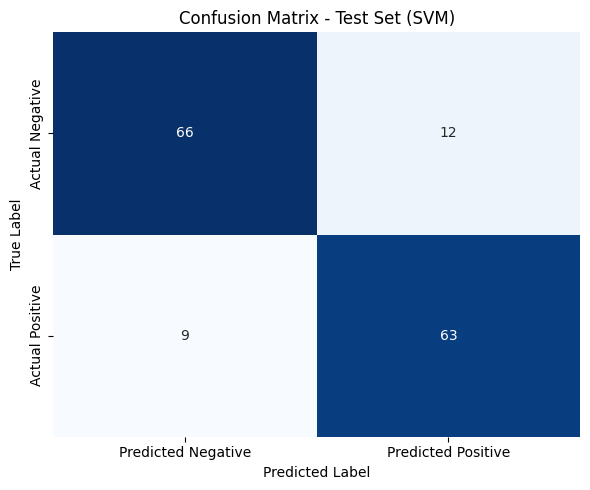

In [19]:
# Plot confusion matrix for test predictions
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"],
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Test Set (SVM)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [20]:
# Summary of results
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nDataset Information:")
print(f"  - Total samples: {len(df)}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Number of features (after encoding): {X_encoded.shape[1]}")
print(f"\nSVM Model Configuration:")
print(f"  - Kernel: RBF (Radial Basis Function)")
print(f"  - C parameter: 1.0")
print(f"  - Gamma: scale")
print(f"  - Number of support vectors: {len(svm_model.support_vectors_)}")
print(f"  - Support vectors per class: {svm_model.n_support_}")

# Calculate detailed metrics for both classes
precision = precision_score(y_test, y_test_pred, average=None)
recall = recall_score(y_test, y_test_pred, average=None)
f1 = f1_score(y_test, y_test_pred, average=None)

print(f"\nModel Performance (Test Set):")
print(f"  Precision (No Heart Disease): {precision[0]:.2f}")
print(f"  Recall (No Heart Disease): {recall[0]:.2f}")
print(f"  F1-Score (No Heart Disease): {f1[0]:.2f}")
print(f"  Precision (Heart Disease): {precision[1]:.2f}")
print(f"  Recall (Heart Disease): {recall[1]:.2f}")
print(f"  F1-Score (Heart Disease): {f1[1]:.2f}")
print(f"  Overall Accuracy: {test_accuracy*100:.2f}%")
print("=" * 70)

FINAL SUMMARY

Dataset Information:
  - Total samples: 746
  - Training samples: 596
  - Test samples: 150
  - Number of features (after encoding): 15

SVM Model Configuration:
  - Kernel: RBF (Radial Basis Function)
  - C parameter: 1.0
  - Gamma: scale
  - Number of support vectors: 273
  - Support vectors per class: [134 139]

Model Performance (Test Set):
  Precision (No Heart Disease): 0.88
  Recall (No Heart Disease): 0.85
  F1-Score (No Heart Disease): 0.86
  Precision (Heart Disease): 0.84
  Recall (Heart Disease): 0.88
  F1-Score (Heart Disease): 0.86
  Overall Accuracy: 86.00%
